In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('lahman_batting.csv')
print(df.shape)
df.head()

(104, 18)


,playerID,yearID,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,POS,AVG
0,troutmi01,2019,LAA,AL,134,470,110,137,25,2,45,104,11,2,110,119,CF,0.291
1,bregmal01,2019,HOU,AL,156,554,122,164,37,1,41,112,17,3,119,83,3B,0.296
2,bellejo01,2019,PIT,NL,143,504,94,161,37,3,37,116,2,3,75,108,1B,0.319
3,moralke01,2019,MIL,NL,144,507,91,148,29,3,37,108,15,5,87,144,1B,0.292
4,bellcodi01,2019,NYA,AL,143,491,77,130,22,1,33,92,4,2,94,158,C,0.265


In [2]:
df.describe()

,yearID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,AVG
count,104.0,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2019.0,114.557692,408.384615,63.557692,110.836538,22.798077,2.240385,18.961538,63.115385,6.865385,2.663462,47.346154,99.451923,0.260990
std,0.0,40.751396,161.602611,31.509846,47.604379,11.044816,1.776301,12.531841,32.466056,7.877777,2.156996,26.304331,41.033701,0.041769
min,2019.0,18.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,2019.0,92.750000,314.750000,44.000000,81.000000,16.000000,1.000000,9.000000,37.750000,1.000000,1.000000,30.000000,79.750000,0.252750
50%,2019.0,128.000000,461.500000,67.500000,123.500000,25.000000,2.000000,17.500000,65.000000,4.000000,2.000000,45.000000,104.500000,0.266000
75%,2019.0,144.250000,527.000000,83.000000,148.250000,30.000000,3.000000,28.250000,87.000000,10.000000,4.000000,65.000000,127.250000,0.279250
max,2019.0,162.000000,627.000000,129.000000,201.000000,54.000000,10.000000,49.000000,126.000000,43.000000,9.000000,119.000000,189.000000,0.349000


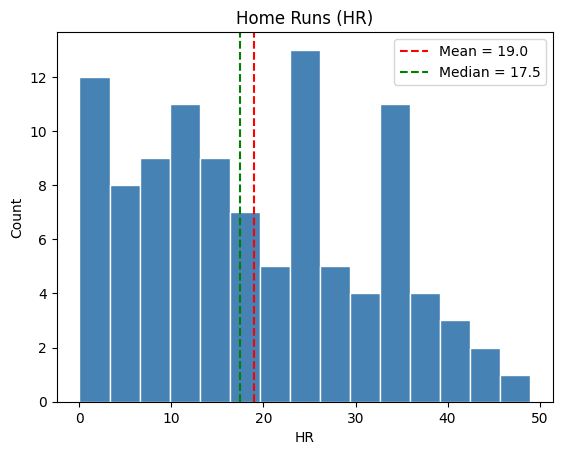

Min:     0
Max:     49
Mean:    18.96
Median:  17.5


In [3]:
plt.hist(df['HR'], bins=15, color='steelblue', edgecolor='white')
plt.axvline(df['HR'].mean(),   color='red',   linestyle='--', label=f'Mean = {df["HR"].mean():.1f}')
plt.axvline(df['HR'].median(), color='green', linestyle='--', label=f'Median = {df["HR"].median()}')
plt.title('Home Runs (HR)')
plt.xlabel('HR')
plt.ylabel('Count')
plt.legend()
plt.show()

print('Min:    ', df['HR'].min())
print('Max:    ', df['HR'].max())
print('Mean:   ', round(df['HR'].mean(), 2))
print('Median: ', df['HR'].median())

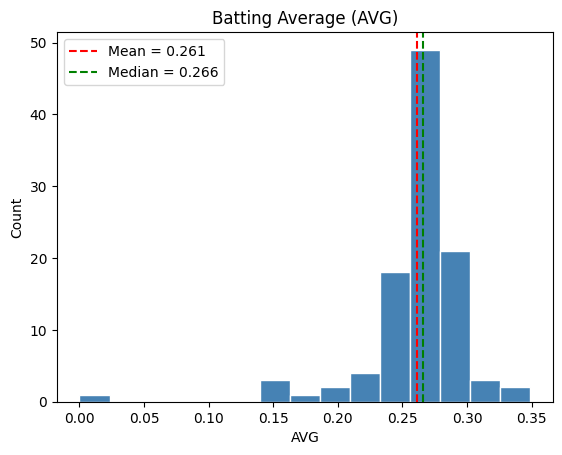

Min:     0.0
Max:     0.349
Mean:    0.261
Median:  0.266


In [4]:
plt.hist(df['AVG'].dropna(), bins=15, color='steelblue', edgecolor='white')
plt.axvline(df['AVG'].mean(),   color='red',   linestyle='--', label=f'Mean = {df["AVG"].mean():.3f}')
plt.axvline(df['AVG'].median(), color='green', linestyle='--', label=f'Median = {df["AVG"].median():.3f}')
plt.title('Batting Average (AVG)')
plt.xlabel('AVG')
plt.ylabel('Count')
plt.legend()
plt.show()

print('Min:    ', df['AVG'].min())
print('Max:    ', df['AVG'].max())
print('Mean:   ', round(df['AVG'].mean(), 3))
print('Median: ', df['AVG'].median())

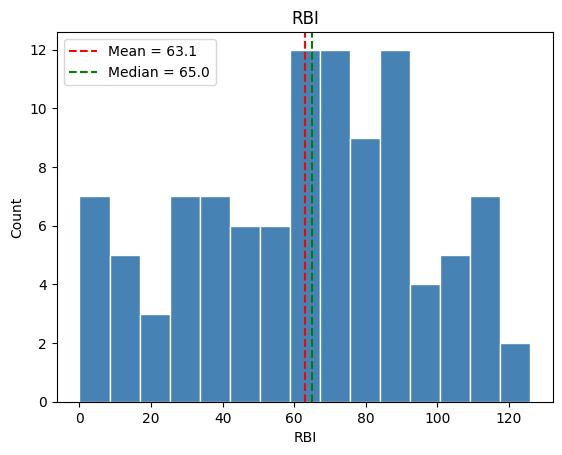

Min:     0
Max:     126
Mean:    63.12
Median:  65.0


In [5]:
plt.hist(df['RBI'], bins=15, color='steelblue', edgecolor='white')
plt.axvline(df['RBI'].mean(),   color='red',   linestyle='--', label=f'Mean = {df["RBI"].mean():.1f}')
plt.axvline(df['RBI'].median(), color='green', linestyle='--', label=f'Median = {df["RBI"].median()}')
plt.title('RBI')
plt.xlabel('RBI')
plt.ylabel('Count')
plt.legend()
plt.show()

print('Min:    ', df['RBI'].min())
print('Max:    ', df['RBI'].max())
print('Mean:   ', round(df['RBI'].mean(), 2))
print('Median: ', df['RBI'].median())

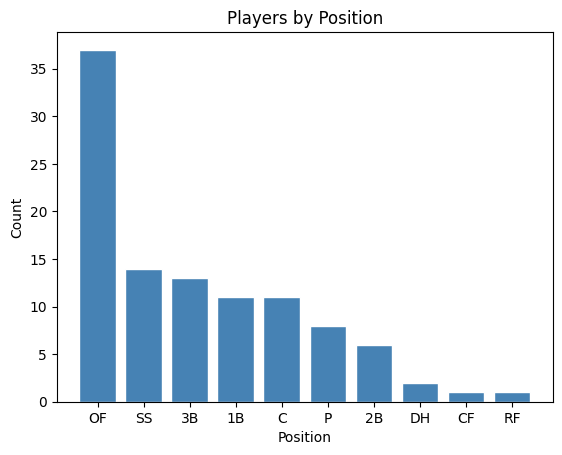

In [6]:
counts = df['POS'].value_counts()
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
plt.title('Players by Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.show()

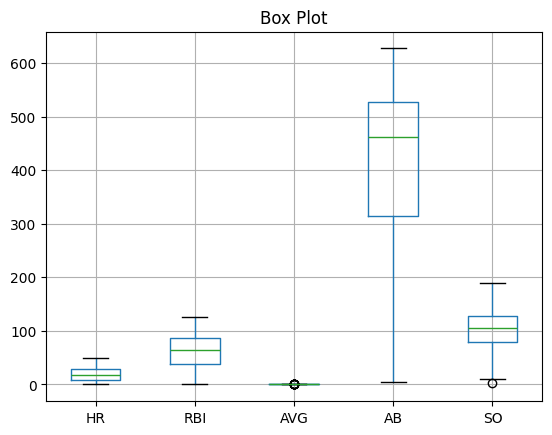

In [7]:
df[['HR', 'RBI', 'AVG', 'AB', 'SO']].boxplot()
plt.title('Box Plot')
plt.show()

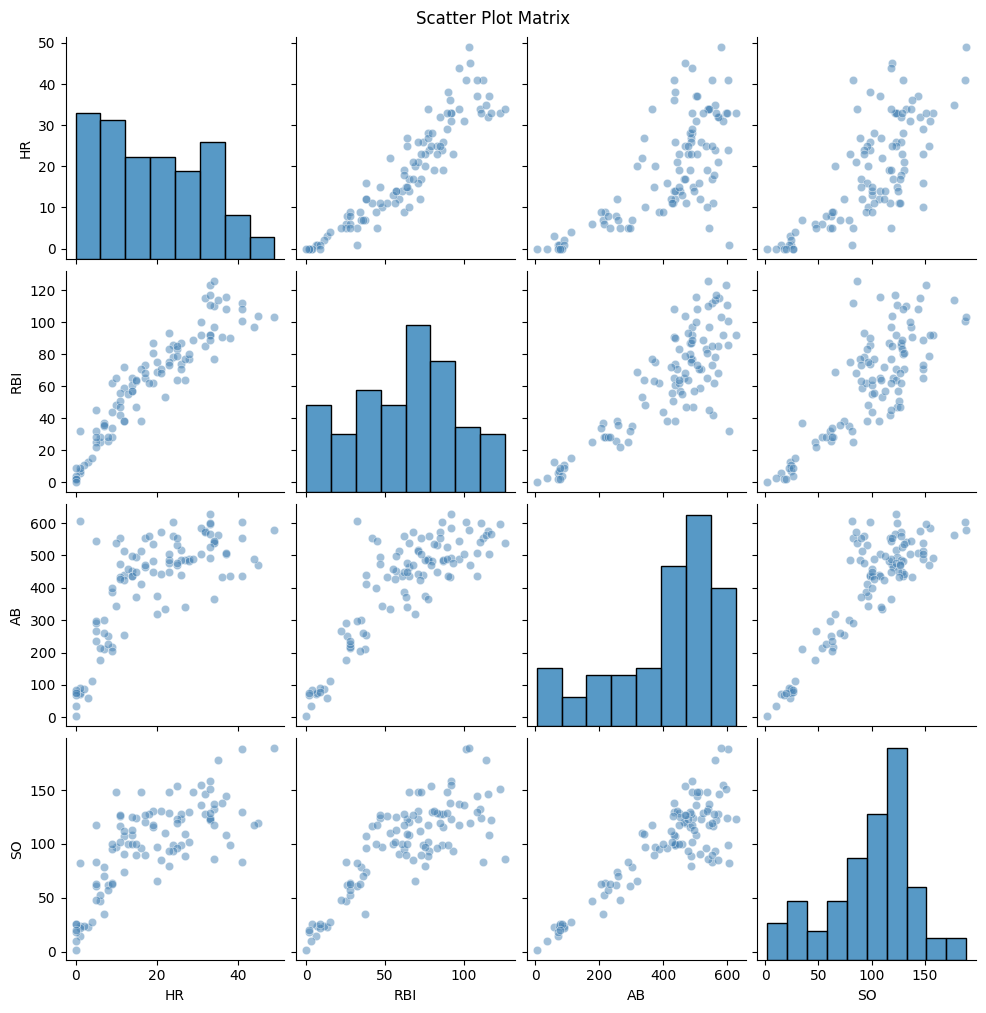

In [8]:
sns.pairplot(df[['HR', 'RBI', 'AB', 'SO']], diag_kind='hist', plot_kws={'alpha': 0.5, 'color': 'steelblue'})
plt.suptitle('Scatter Plot Matrix', y=1.01)
plt.show()

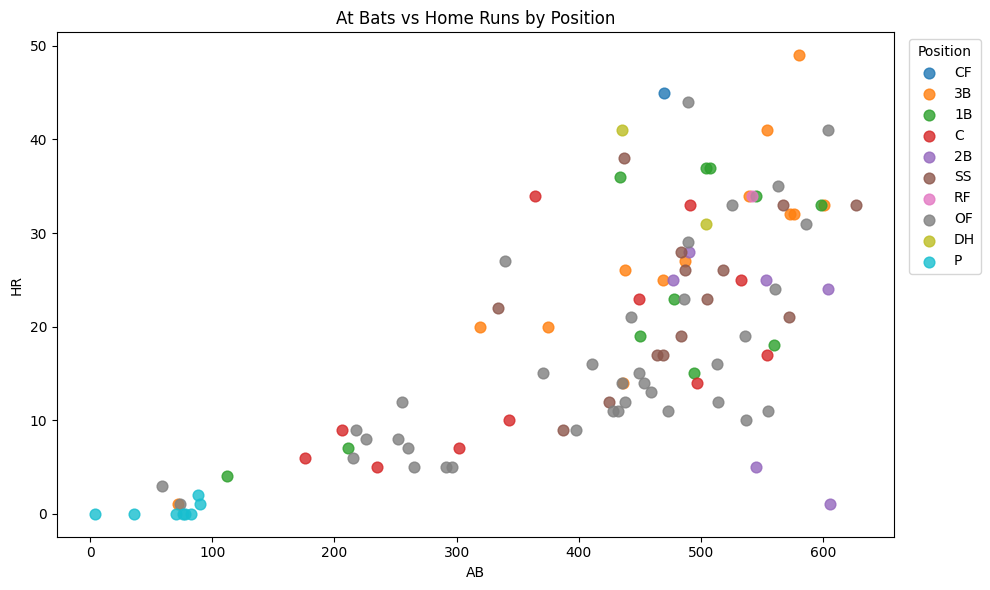

In [9]:
positions = df['POS'].unique()
colors = plt.cm.tab10.colors

plt.figure(figsize=(10, 6))
for i, pos in enumerate(positions):
    subset = df[df['POS'] == pos]
    plt.scatter(subset['AB'], subset['HR'], label=pos, color=colors[i % len(colors)], alpha=0.8, s=60)

plt.title('At Bats vs Home Runs by Position')
plt.xlabel('AB')
plt.ylabel('HR')
plt.legend(title='Position', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()